In [1]:
import numpy as np
import torch
import json

from data.dataset import LandmarksDataset, ToTensor, ToTensorWithSeg
from data.transforms import Scale
from models.hybridgnet_se_resnext_dual import HybridDual
from models.hybridgnet_se_resnext import Hybrid
from models.utils import load_config
from torchvision import transforms

Load model, configs and import test dataset

In [2]:
DATASET = '../Dataset/CAMUS/Landmarks_3_10'
NAME = 'CAMUS_Image_2_Graph_NN_dual_batched'

hyperparameters = json.load(open("../Training/%s/hyperparameters.json"%NAME))
hyperparameters['naive'] = False

config, D_t, U_t, A_t = load_config(DATASET, hyperparameters)
config['resume'] = "../Training/%s/%s.pth"%(NAME, NAME)
config['raster_as_input'] = False

if "dual" in NAME.lower():
    model = HybridDual(config, D_t, U_t, A_t).to(config['device'])
else:
    model = Hybrid(config, D_t, U_t, A_t).to(config['device'])

print("Image Encoder filters", model.encoder.filters + [model.encoder.filters[-1]])
print("Bottleneck latents", model.encoder.latents)
print("Graph convolutional filters", config['filters'][::-1])

if config['resume']:
    model.load_checkpoint(config['resume'], config['device'])

model.eval()
    
images = np.loadtxt("%s/test.txt"%DATASET, dtype = str)
val_dataset = LandmarksDataset(images, "%s/images"%DATASET, "%s/landmarks"%DATASET, 
                               transform = transforms.Compose([Scale(config['inputsize']), ToTensorWithSeg()]))

Configuration
database_path : ../CAMUS/Resources/database_nifti
output_path : ../Dataset/CAMUS/Landmarks_3_10
scale_factor : 0.1
resolutions : ['full', 'half', 'quarter']
image_types : ['2CH', '4CH']
organs : ['1', '2', '3']
organ_names : ['LV Endo', 'LV Myo', 'LA']
inputsize : 512

Loading adjacency matrices ../Dataset/CAMUS/Landmarks_3_10/NonNaive/adj_full_block_diagonal.npy


/home/ngaggion/Documents/Mask2Graph/Repo/models/utils.py:14: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  sparse_tensor = torch.sparse.FloatTensor(i, v, torch.Size(shape))


Image Encoder filters [16, 32, 64, 128, 256, 256]
Bottleneck latents 64
Graph convolutional filters [32, 32, 24, 24, 16, 16, 8, 2]


In [3]:
import matplotlib.pyplot as plt
from training.utils import initialize_edge_matrices_and_organ_counts

if not config['naive']:
    with open(f"{DATASET}/NonNaive/organ_order.json", "r") as f:
        circ_organ_order = json.load(f)

print(circ_organ_order['1'])

edge_matrices, organ_ids, organ_order, organ_counts = initialize_edge_matrices_and_organ_counts(DATASET, config['device'], config)

sample1 = val_dataset[234]
out1 = model(sample1['image'].unsqueeze(0).to(config['device']))[0]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 191, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 192, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 189]
Using non-naive adjacency matrix


/home/ngaggion/miniconda3/envs/hybridgnet/lib/python3.13/site-packages/torch/nn/modules/instancenorm.py:115: UserWarning: input's size at dim=1 does not match num_features. You can silence this warning by not passing in num_features, which is not used because affine=False
  warnings.warn(


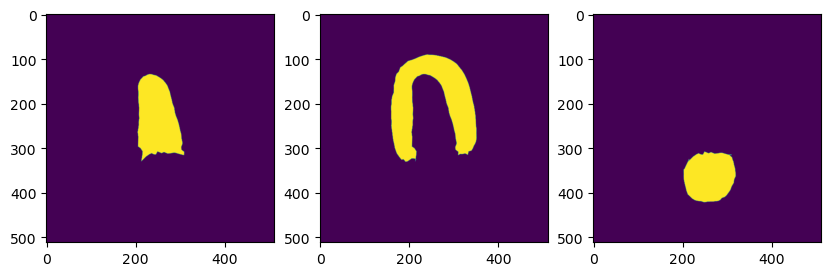

In [4]:
seg = model.raster_non_naive(out1[0].unsqueeze(0), organ_ids[0], circ_organ_order, config['inputsize'])

plt.figure(figsize=(10,10))
plt.subplot(1,3,1)
plt.imshow(seg[0, 0].cpu().detach().numpy())
plt.subplot(1,3,2)
plt.imshow(seg[0, 1].cpu().detach().numpy())
plt.subplot(1,3,3)
plt.imshow(seg[0, 2].cpu().detach().numpy())
plt.show()

Dual output shape torch.Size([3, 512, 512])


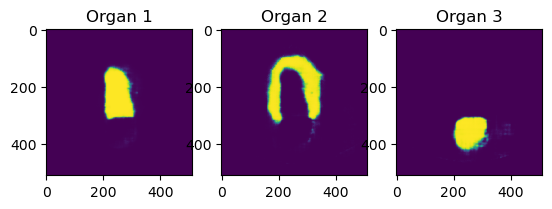

In [5]:
if "dual" in NAME.lower():
    seg = model(sample1['image'].unsqueeze(0).to(config['device']))[2][0]
    print("Dual output shape", seg.shape)
    
    for i in range(seg.shape[0]):
        plt.subplot(1, seg.shape[0], i+1)
        plt.imshow(seg[i].cpu().detach().numpy())
        plt.title(f"Organ {i+1}")
    plt.show()

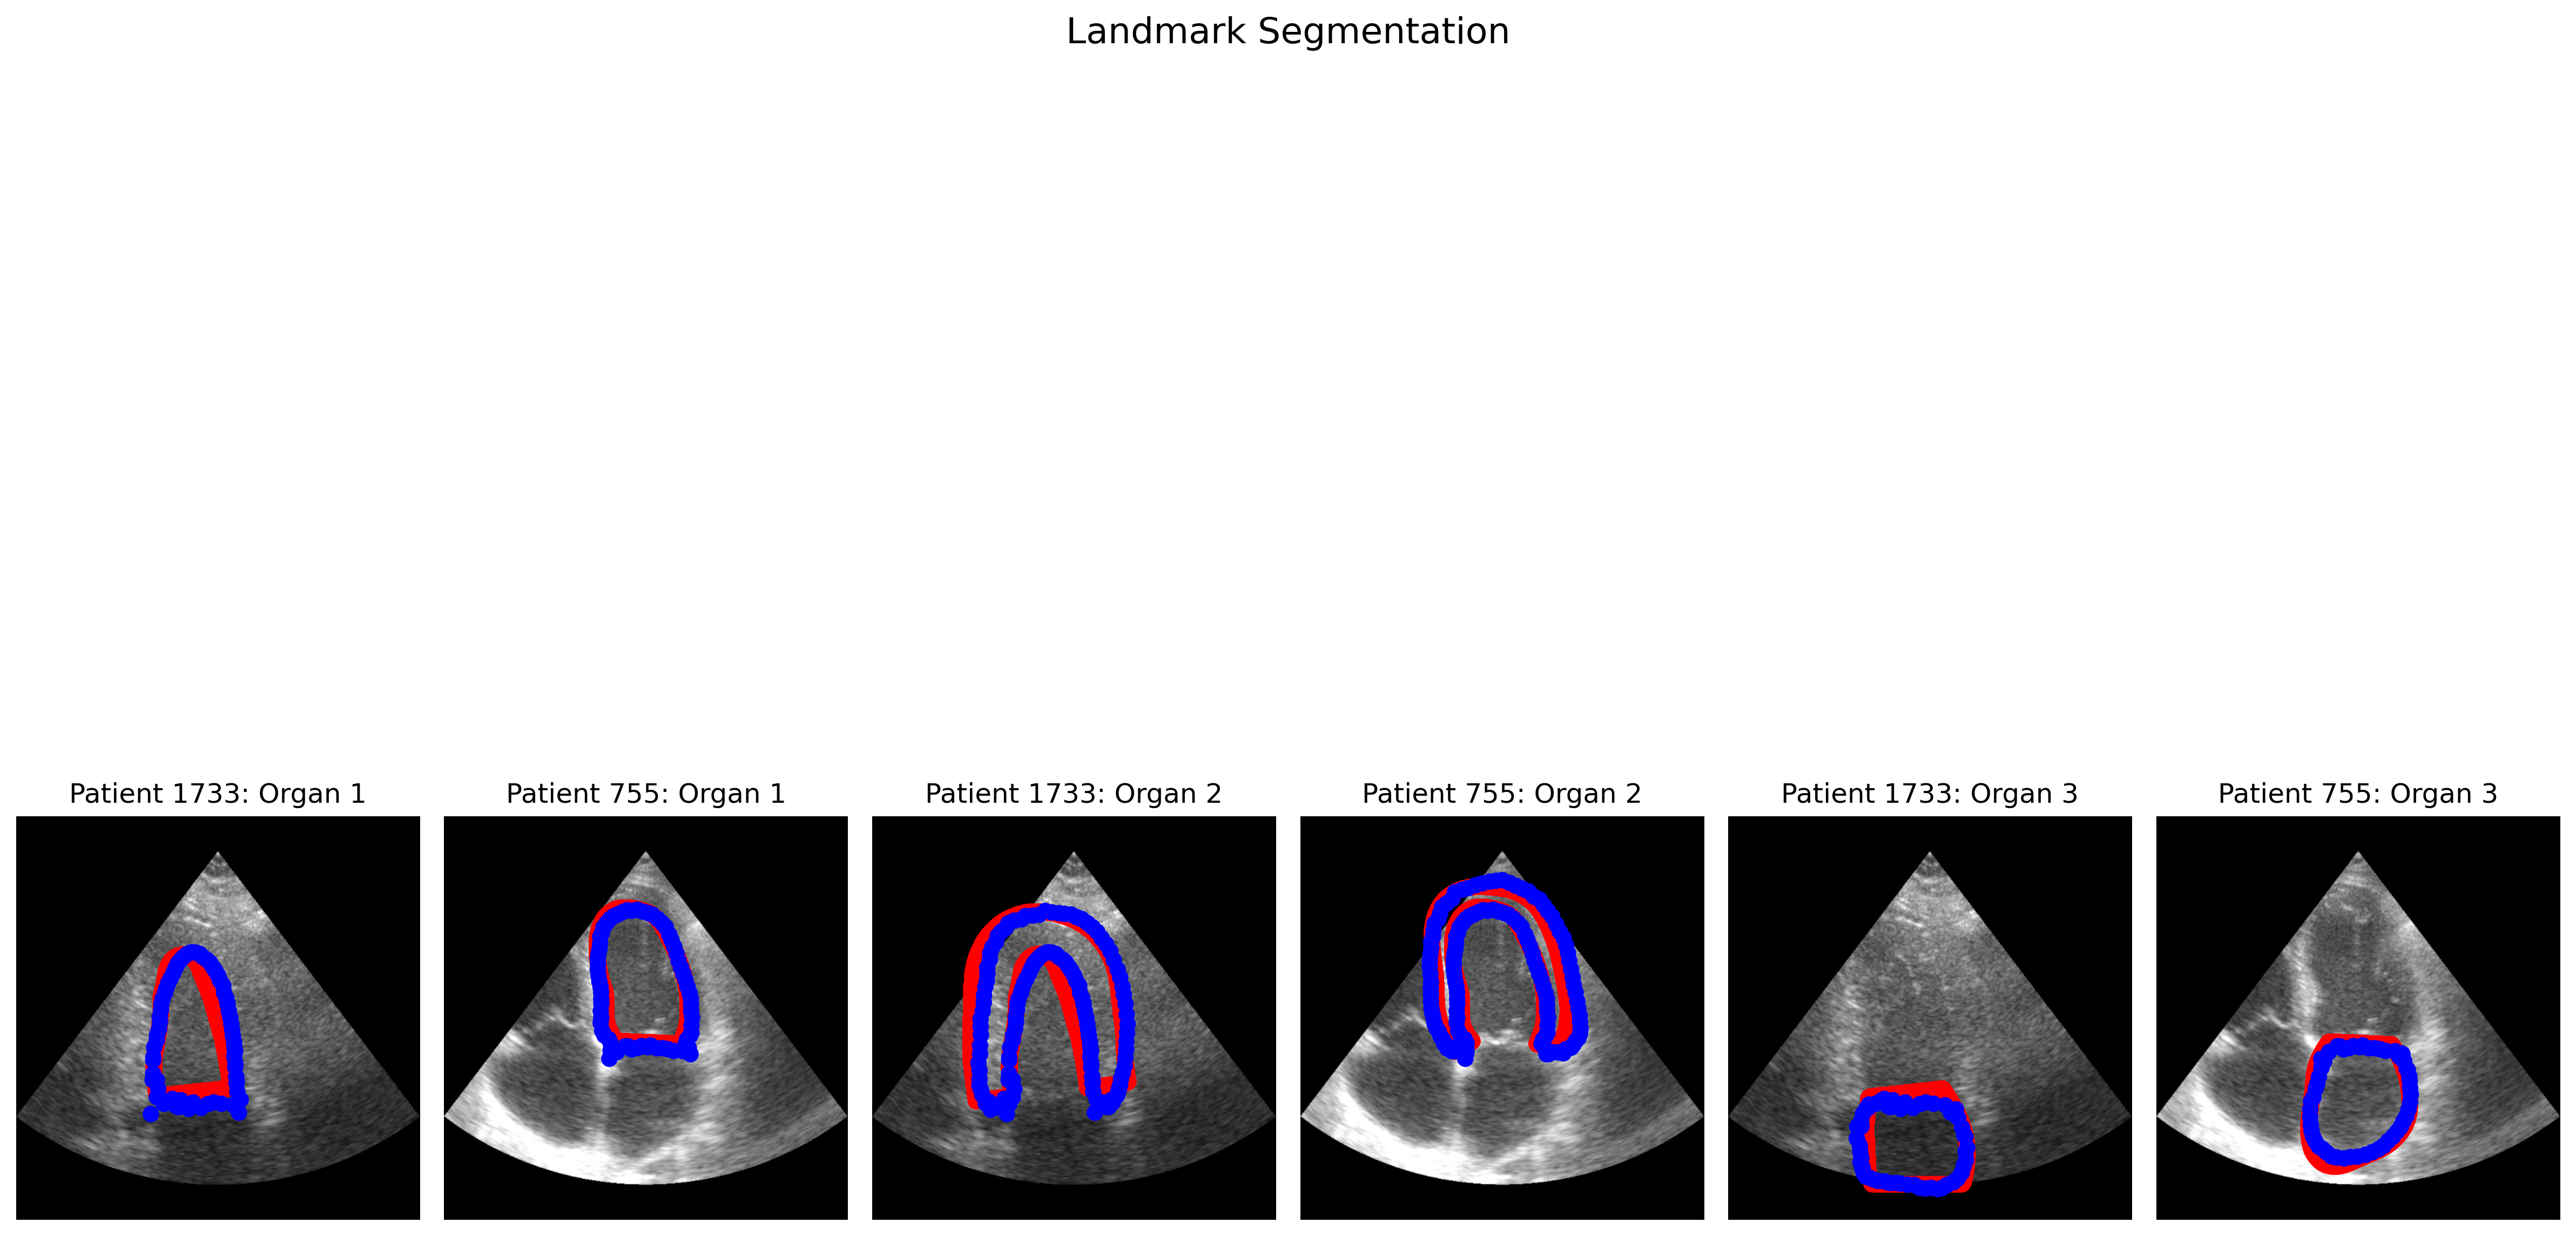

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import random
from utils.image_processing import draw_lines, draw_organ

# Load organ IDs
organ_id = np.load("%s/NonNaive/adj_full_organ_id.npy" % DATASET)[:,0]

unique_organs = set()
for org_str in organ_id:
    for org in str(org_str).split('-'):
        if org:  # Skip empty strings
            unique_organs.add(org)

organ_order = sorted(list(unique_organs))

# Enable interactive mode
plt.ion()

# Create a figure with appropriate size
plt.figure(figsize=(16, 12), dpi=300)

# Number of sample pairs to display
num_samples = 1

# Randomly select indices from the validation set
random_indices = random.sample(range(len(val_dataset)), num_samples * 2)
# Split indices into two groups for side-by-side comparison
comparison_pairs = [(random_indices[i], random_indices[i+num_samples]) for i in range(num_samples)]

# For each randomly selected pair of samples
for j, (idx1, idx2) in enumerate(comparison_pairs):
    # Get the two samples from validation set
    sample1 = val_dataset[idx1]
    image1, landmarks1, raster1 = sample1['image'], sample1['landmarks'], sample1['raster']
    
    sample2 = val_dataset[idx2]
    image2, landmarks2, raster2 = sample2['image'], sample2['landmarks'], sample2['raster']
    
    # Run model inference
    out1 = model(image1.unsqueeze(0).to(config['device']))[0]
    out1 = out1 * config['inputsize']
    output1 = out1.squeeze(0).cpu().detach().numpy()
    
    out2 = model(image2.unsqueeze(0).to(config['device']))[0]
    out2 = out2 * config['inputsize']
    output2 = out2.squeeze(0).cpu().detach().numpy()
    
    # Convert tensors to numpy arrays
    img1 = image1.squeeze(0).cpu().detach().numpy()
    img2 = image2.squeeze(0).cpu().detach().numpy()
    
    # Get organ labels
    organs1 = landmarks1[:, 2].cpu().numpy()
    organs2 = landmarks2[:, 2].cpu().numpy()
    
    # Plot each organ
    i = 1
    for organ in organ_order:
        # Skip if this organ doesn't exist in both samples
        if int(organ) not in organs1 or int(organ) not in organs2:
            continue
            
        # Get indices for this organ, need to check if organ is in any of the values of the list to get a boolean array
        # This is a workaround since the organ_id is a string with many organs and we need to check if it contains the organ
        idx_organ = np.zeros(output1.shape[0], dtype=bool)
        for k in range(len(organ_id)):
            if organ in str(organ_id[k]).split('-'):
                idx_organ[k] = True
        
        idx_target1 = organs1 == int(organ)
        idx_target2 = organs2 == int(organ)
        
        # Plot first sample
        ax1 = plt.subplot(num_samples, 6, i + j*6)
        plt.imshow(img1, cmap='gray')
        target1 = landmarks1[idx_target1, :2]
        target1 = target1 * config['inputsize']
        
        # Draw ground truth and predictions
        draw_organ(ax1, target1, 'r')
        draw_organ(ax1, output1[idx_organ])
        plt.title(f"Patient {idx1}: Organ {int(organ)}")
        plt.axis('off')
        
        # Plot second sample (side by side)
        ax2 = plt.subplot(num_samples, 6, i+1 + j*6)
        plt.imshow(img2, cmap='gray')
        target2 = landmarks2[idx_target2, :2]
        target2 = target2 * config['inputsize']
        
        # Draw ground truth and predictions
        draw_organ(ax2, target2, 'r')
        draw_organ(ax2, output2[idx_organ])
        plt.title(f"Patient {idx2}: Organ {int(organ)}")
        plt.axis('off')
        
        i += 2
        
        # If we've shown 3 organs, move to next row
        if i > 5:
            break

# Add a title for the entire figure
plt.suptitle("Landmark Segmentation", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for suptitle

plt.show()

In [7]:
# Create a second figure for numbered landmarks without background
plt.figure(figsize=(32, 24), dpi=300)

# For each randomly selected pair of samples again
for j, (idx1, idx2) in enumerate(comparison_pairs):
    # Get the two samples from validation set
    sample1 = val_dataset[idx1]
    landmarks1 = sample1['landmarks']
    
    sample2 = val_dataset[idx2]
    landmarks2 = sample2['landmarks']
    
    # Run model inference to get predictions
    out1 = model(sample1['image'].unsqueeze(0).to(config['device']))[0]
    out1 = out1 * config['inputsize']
    output1 = out1.squeeze(0).cpu().detach().numpy()
    
    out2 = model(sample2['image'].unsqueeze(0).to(config['device']))[0]
    out2 = out2 * config['inputsize']
    output2 = out2.squeeze(0).cpu().detach().numpy()
    
    # Get organ labels
    organs1 = landmarks1[:, 2].cpu().numpy()
    organs2 = landmarks2[:, 2].cpu().numpy()
    
    # Plot each organ
    i = 1
    for organ in organ_order:
        # Skip if this organ doesn't exist in both samples
        if int(organ) not in organs1 or int(organ) not in organs2:
            continue
            
        # Get indices for this organ, need to check if organ is in any of the values of the list to get a boolean array
        # This is a workaround since the organ_id is a string with many organs and we need to check if it contains the organ
        idx_organ = np.zeros(output1.shape[0], dtype=bool)
        for k in range(len(organ_id)):
            if organ in str(organ_id[k]).split('-'):
                idx_organ[k] = True
            
        idx_target1 = organs1 == int(organ)
        idx_target2 = organs2 == int(organ)
        
        # Get predicted landmark points
        pred1 = output1[idx_organ]
        pred2 = output2[idx_organ]
        
        # Create blank white background for first patient
        ax1 = plt.subplot(num_samples, 6, i + j*6)
        ax1.set_facecolor('white')
        
        # Set appropriate axis limits based only on prediction coordinates
        max_x = np.max(pred1[:, 0])
        max_y = np.max(pred1[:, 1])
        min_x = np.min(pred1[:, 0])
        min_y = np.min(pred1[:, 1])
        
        # Add some padding
        padding = 20
        ax1.set_xlim(min_x - padding, max_x + padding)
        ax1.set_ylim(max_y + padding, min_y - padding)  # Inverted y-axis for image coordinates
        
        # Number each landmark
        for k, (x, y) in enumerate(pred1):
            ax1.text(x, y, str(k), fontsize=9, ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        
        # Add title
        plt.title(f"Patient {idx1}: Organ {int(organ)}")
        plt.axis('on')
        ax1.set_xticks([])
        ax1.set_yticks([])
        
        # Create blank white background for second patient
        ax2 = plt.subplot(num_samples, 6, i+1 + j*6)
        ax2.set_facecolor('white')
        
        # Set appropriate axis limits based only on prediction coordinates
        max_x = np.max(pred2[:, 0])
        max_y = np.max(pred2[:, 1])
        min_x = np.min(pred2[:, 0])
        min_y = np.min(pred2[:, 1])
        
        # Add some padding
        ax2.set_xlim(min_x - padding, max_x + padding)
        ax2.set_ylim(max_y + padding, min_y - padding)  # Inverted y-axis for image coordinates
        
        # Number each landmark
        for k, (x, y) in enumerate(pred2):
            ax2.text(x, y, str(k), fontsize=9, ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        
        # Add title
        plt.title(f"Patient {idx2}: Organ {int(organ)}")
        plt.axis('on')
        ax2.set_xticks([])
        ax2.set_yticks([])
        
        i += 2
        
        # If we've shown 3 organs, move to next row
        if i > 5:
            break

# Add a title for the entire figure
plt.suptitle("Numbered Landmark Correspondence Between Patients", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for suptitle


In [8]:
ids = "/home/ngaggion/SSD/Mask2Graph/Dataset/CAMUS/Landmarks_3_10/NonNaive/adj_full_organ_id.npy"
organ_id = np.load(ids)
print(organ_id[169])
print(organ_id[170])
print(organ_id[171])

FileNotFoundError: [Errno 2] No such file or directory: '/home/ngaggion/SSD/Mask2Graph/Dataset/CAMUS/Landmarks_3_10/NonNaive/adj_full_organ_id.npy'